# Inverse Kinematics for the myCobot 280 Labs
## Lab 3: Numerical IK, Damped Least Squares, and Convergence Debugging

Run this notebook from `~/venvs/mycobot`:

```bash
source ~/venvs/mycobot/bin/activate
jupyter lab
```

This lab continues Lab 1 (spatial transformations) and Lab 2 (manual FK vs URDF FK). Later labs can send live end-effector commands on `/mycobot/ee_pose` as `[x_mm, y_mm, z_mm, roll_deg, pitch_deg, yaw_deg]`, but all offline IK work in this notebook uses metres and radians.
        


In [29]:
%matplotlib widget
import os
import numpy as np
import matplotlib.pyplot as plt
import roboticstoolbox as rtb

from spatialmath import SE3
from scipy.optimize import least_squares, minimize

from helperFunctions import poseError, calculate_poseerror, transform_to_pipi, rpy_to_rot, rpy_to_transform

## Setup

### 1. Import the myCobot 280 URDF model

Load the URDF model distributed with this notebook. In the lab codebase the kinematic chain of interest runs from `g_base` to `joint6_flange`. Inspect the model and link names so that you know which chain you are solving.

Unlike the early textbook examples, this lab uses the URDF model directly: fixed `origin xyz/rpy` transforms are combined with the individual joint-axis rotations, rather than a DH-only chain.

**Pose-error formulation used in this lab:** The helper functions in `helperFunctions.py` compute the same 6D error as the myCobot 280 controller codebase. Position error is the 3D vector `target_pos - achieved_pos` in metres. Rotation error is extracted as an axis-angle vector from the relative rotation matrix `target_rot @ achieved_rot.T`, matching the `_rot_to_vec` method in `mycobot_control.py`. The full 6D error is `[pos_error(3), rot_error(3)]`.

In [30]:
notebook_path = os.getcwd()
mycobot_urdf_path = os.path.join(notebook_path, 'mycobot_280_gazebo.urdf')
mycobot = rtb.Robot.URDF(mycobot_urdf_path)
print(mycobot)

for link in mycobot.links:
    print(link.name)
        


ERobot: mycobot_280_gazebo, 6 joints (RRRRRR), dynamics, geometry, collision
┌──────┬────────────────┬───────┬────────┬─────────────────────────────────────────────────────┐
│ link │      link      │ joint │ parent │                 ETS: parent to link                 │
├──────┼────────────────┼───────┼────────┼─────────────────────────────────────────────────────┤
│    0 │ world          │       │ BASE   │ SE3()                                               │
│    1 │ g_base         │       │ world  │ SE3()                                               │
│    2 │ joint1         │       │ g_base │ SE3()                                               │
│    3 │ joint2         │     0 │ joint1 │ SE3(0, 0, 0.1396) ⊕ Rz(q0)                          │
│    4 │ joint3         │     1 │ joint2 │ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1)          │
│    5 │ joint4         │     2 │ joint3 │ SE3(-0.1104, 0, 0) ⊕ Rz(q2)                         │
│    6 │ joint5         │     3 │ joint4 │ SE3(-0.

/tmp/ipykernel_122548/1395879295.py:3: DeprecationWarning: Robot.URDF() is deprecated. Subclass roboticstoolbox.models.URDF.URDFRobot, or call URDF_read() from that module and construct Robot directly.
  mycobot = rtb.Robot.URDF(mycobot_urdf_path)


### 2. Inspect the chain used for IK

Create the kinematic model that you will use for inverse kinematics. In this lab the end-effector comparison is made at `joint6_flange`. If your Robotics Toolbox version exposes explicit start and end selection, compare the chain from `g_base` to `joint6_flange`; otherwise use the model ending at `joint6_flange`.
        


In [31]:
bodyname = 'joint6_flange'
mycobot_ets = mycobot.ets(end=bodyname)
print(mycobot_ets)
print(f'Number of joints: {mycobot.n}')
        


SE3() ⊕ SE3() ⊕ SE3(0, 0, 0.1396) ⊕ Rz(q0) ⊕ SE3(0, 0, -0.001; 180°, 90°, 90°) ⊕ Rz(q1) ⊕ SE3(-0.1104, 0, 0) ⊕ Rz(q2) ⊕ SE3(-0.096, 0, 0.06462; 0°, -0°, -90°) ⊕ Rz(q3) ⊕ SE3(0, -0.07318, -0.001; -90°, -90°, 180°) ⊕ Rz(q4) ⊕ SE3(0, 0.0456, 0; -90°, -0°, 0°) ⊕ Rz(q5)
Number of joints: 6


## The Hard Problem

Inverse kinematics is harder than forward kinematics because the same target pose can admit multiple joint solutions, no exact solution, or solutions that depend strongly on the initial guess. In this lab you will compare three practical numerical approaches for the myCobot 280:

- toolbox-based IK
- generic nonlinear least-squares IK
- custom damped least-squares Jacobian IK

### 3. Generate a Robotics Toolbox IK solver

Use a full six-element task-space mask so that both position and orientation are included in the solve.

In [32]:
mask = [1, 1, 1, 1, 1, 1]
ik_mycobot = rtb.IK_LM(mask=mask)
        


### 4. Define a realistic myCobot 280 target pose

Build a target pose from a translation and an RPY orientation, consistent with Labs 1 and 2. Start from a reachable pose such as `x=0.18 m`, `y=0.04 m`, `z=0.18 m` and moderate angles. If a solve fails, reduce the orientation demand or move the target closer to the base.

Keep everything in metres and radians inside this notebook. Only the live controller topic `/mycobot/ee_pose` uses millimetres and degrees.
        


In [33]:
target_xyz_m = np.array([0.18, 0.04, 0.18])
target_rpy_rad = np.array([0.0, np.deg2rad(35.0), np.deg2rad(20.0)])

# Build the target pose using the same RPY convention as the codebase:
# rpy_to_transform takes [x,y,z] and [roll,pitch,yaw], builds R = Rz(yaw) @ Ry(pitch) @ Rx(roll)
target_pose = SE3(rpy_to_transform(target_xyz_m, target_rpy_rad))

print(target_pose)

   0.7698   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04      
  -0.5736    0         0.8192    0.18      
   0         0         0         1         



### 5. Solve IK from a zero seed

Use the zero configuration as the first seed. Record whether the solve succeeds, the returned residual, and the final joint vector.
        


In [34]:
q0_zero = np.zeros(mycobot.n)
q_toolbox, success, iterations, searches, residual, reason = ik_mycobot.solve(
    mycobot_ets,
    target_pose,
    q0_zero,
)

print('success:', success)
print('iterations:', iterations)
print('searches:', searches)
print('residual:', residual)
print('reason:', reason)
print('q_toolbox:', transform_to_pipi(q_toolbox))
        


success: True
iterations: 50
searches: 2
residual: 4.5724063556626123e-07
reason: Success
q_toolbox: [ 2.92631064  0.13163988  2.23645419 -0.26277136 -0.31168526 -1.09238192]


### 6. Evaluate the achieved pose and task-space error

Compare the target pose with the achieved pose from forward kinematics. Use the helper functions from earlier labs to evaluate the pose error in task space.
        


In [35]:
achieved_pose_toolbox = mycobot.fkine(q_toolbox)
poseerror_toolbox = calculate_poseerror(q_toolbox, mycobot, bodyname, target_pose)
poseerror_toolbox_direct = poseError(target_pose, achieved_pose_toolbox)

print('myCobot 280')
print('Target pose:\n', target_pose)
print('Achieved pose:\n', achieved_pose_toolbox)
print('Helper-function ||e(q)||:', np.linalg.norm(poseerror_toolbox))
print('Direct poseError ||e||:', np.linalg.norm(poseerror_toolbox_direct))

myCobot 280
Target pose:
    0.7698   -0.342     0.539     0.18      
   0.2802    0.9397    0.1962    0.04      
  -0.5736    0         0.8192    0.18      
   0         0         0         1         

Achieved pose:
    0.7696   -0.342     0.5392    0.1794    
   0.2802    0.9397    0.196     0.04021   
  -0.5737    0.0002681  0.8191    0.1794    
   0         0         0         1         

Helper-function ||e(q)||: 0.0009562851411229398
Direct poseError ||e||: 0.0009562851411229398


## Multiple Seed Strategies

### 7. Compare several initial guesses

A numerical IK solver can converge to different local solutions, or fail, depending on its starting configuration. Test the same target from several seeds and compare convergence, residual, and final joint vectors.

In [36]:
# Arbitrary seed candidates for comparison (codebase geometric seeds are explored in the next task)
seed_candidates = {
    'zero': np.zeros(mycobot.n),
    'seed_a': np.array([0.0, 0.4, -0.6, 0.0, 0.4, 0.0]),
    'seed_b': np.array([0.3, -0.2, 0.5, -0.4, 0.2, 0.1]),
    'seed_c': np.array([-0.4, 0.1, -0.3, 0.6, -0.2, 0.0]),
}

toolbox_seed_results = {}

for seed_name, q0 in seed_candidates.items():
    q_sol, success, iterations, searches, residual, reason = ik_mycobot.solve(
        mycobot_ets,
        target_pose,
        q0,
    )

    toolbox_seed_results[seed_name] = {
        'success': success,
        'iterations': iterations,
        'searches': searches,
        'residual': residual,
        'reason': reason,
        'q': transform_to_pipi(q_sol),
    }

toolbox_seed_results

{'zero': {'success': True,
  'iterations': 83,
  'searches': 4,
  'residual': 1.6968194935589307e-07,
  'reason': 'Success',
  'q': array([ 2.92736149,  0.13140934,  2.23059919, -0.25632333, -0.31133375,
         -1.09350077])},
 'seed_a': {'success': True,
  'iterations': 51,
  'searches': 3,
  'residual': 1.4625786864333532e-08,
  'reason': 'Success',
  'q': array([ 2.92605814,  0.13292572,  2.22844991, -0.256363  , -0.31195809,
         -1.09221234])},
 'seed_b': {'success': True,
  'iterations': 46,
  'searches': 2,
  'residual': 6.80390097424142e-08,
  'reason': 'Success',
  'q': array([ 2.92657634,  0.1334842 ,  2.22963773, -0.2578765 , -0.31167801,
         -1.09269235])},
 'seed_c': {'success': True,
  'iterations': 48,
  'searches': 2,
  'residual': 1.8010011028894585e-10,
  'reason': 'Success',
  'q': array([ 2.92574383,  0.13163521,  2.22766946, -0.25441861, -0.31210696,
         -1.09191003])}}

### 8. Reproduce the codebase geometric seed strategy

The myCobot 280 controller uses three seed strategies when solving IK in `_solve_ik()`:

1. **Current joint angles** — the best seed when the robot is already near the target.
2. **Geometric elbow-down** — J1 points at the target XY, remaining joints set to a stretched-down pose: `[atan2(ty, tx), -0.5236, -1.5708, -0.7854, 0.0, 0.0]`.
3. **Geometric elbow-up** — Same J1, but with an elbow-up configuration: `[atan2(ty, tx), -0.7854, -1.0472, -1.0472, 0.0, 0.0]`.

The geometric seeds point J1 toward the target in the XY plane, which gives the Jacobian solver a good starting direction for far-reaching targets. Reproduce these seeds for your target pose and compare them with the arbitrary seeds from the previous task.

In [37]:
# Codebase geometric seed strategy (from _solve_ik in mycobot_control.py)
target_pos = target_pose.A[:3, 3]
j1_guess = np.arctan2(target_pos[1], target_pos[0])

seed_current = np.zeros(mycobot.n)  # placeholder for "current joint angles"
seed_elbow_down = np.array([j1_guess, -0.5236, -1.5708, -0.7854, 0.0, 0.0])
seed_elbow_up = np.array([j1_guess, -0.7854, -1.0472, -1.0472, 0.0, 0.0])

codebase_seeds = {
    'current_angles': seed_current,
    'geometric_elbow_down': seed_elbow_down,
    'geometric_elbow_up': seed_elbow_up,
}

codebase_seed_results = {}

for seed_name, q0 in codebase_seeds.items():
    q_sol, success, iterations, searches, residual, reason = ik_mycobot.solve(
        mycobot_ets,
        target_pose,
        q0,
    )
    codebase_seed_results[seed_name] = {
        'success': success,
        'iterations': iterations,
        'residual': residual,
        'q': transform_to_pipi(q_sol),
    }

codebase_seed_results

{'current_angles': {'success': True,
  'iterations': 45,
  'residual': 4.461264753894937e-09,
  'q': array([ 2.92564099,  0.13075627,  2.22809056, -0.25398791, -0.31217051,
         -1.09182248])},
 'geometric_elbow_down': {'success': True,
  'iterations': 38,
  'residual': 3.2198706247572596e-10,
  'q': array([ 2.92574382,  0.13167562,  2.22776239, -0.25456534, -0.31211654,
         -1.09190767])},
 'geometric_elbow_up': {'success': True,
  'iterations': 86,
  'residual': 3.7130712615699826e-07,
  'q': array([ 2.9264906 ,  0.13469166,  2.2345899 , -0.26404121, -0.31166715,
         -1.09257695])}}

## Numerical vs Analytical IK

Analytical IK uses closed-form formulas when a robot structure allows them. Numerical IK iteratively reduces pose error and is usually easier to adapt to a URDF-based model.

For the myCobot 280 lab series, the practical focus is numerical IK. The controller and debugging workflow are built around the URDF model, Jacobians, seeds, residuals, and convergence behaviour rather than a separate closed-form solver.

## Generic Nonlinear Least-Squares IK

### 9. Build the optimization objective

Reuse `calculate_poseerror(q, robot, bodyname, targetpose)` as the residual function for `least_squares`. If you also want to try `minimize`, wrap the residual in a scalar sum-of-squares objective.

In [38]:
def calculate_scalar_poseerror(q, robot, bodyname, targetpose, errorweights=None):
    if errorweights is None:
        errorweights = np.ones(6)
    e = calculate_poseerror(q, robot, bodyname, targetpose, errorweights)
    return 0.5 * np.sum(e**2)
        


### 10. Solve the IK problem with `least_squares` and optionally `minimize`

Use Levenberg-Marquardt as the main path. BFGS is optional and only makes sense with the scalar objective. Compare these results against the toolbox solver.

In [39]:
q0_lm = np.zeros(mycobot.n)

q_lm = least_squares(
    calculate_poseerror,
    q0_lm,
    method='lm',
    ftol=1e-6,
    xtol=1e-6,
    gtol=1e-6,
    args=(mycobot, bodyname, target_pose),
)

q_bfgs = minimize(
    calculate_scalar_poseerror,
    q0_lm,
    args=(mycobot, bodyname, target_pose),
    method='BFGS',
    tol=1e-6,
)

print('LM q:', transform_to_pipi(q_lm.x))
print('LM ||e||:', np.linalg.norm(q_lm.fun))
print('BFGS q:', transform_to_pipi(q_bfgs.x))
print('BFGS cost:', q_bfgs.fun)
        


LM q: [ 0.61026107 -0.12201789 -2.18535906  0.1418266  -2.99293663 -1.78635367]
LM ||e||: 3.317173991891821e-14
BFGS q: [ 6.16738515e-01 -1.74839172e+00 -8.67217370e-05  2.72517679e+00
 -1.52326396e-01  1.34983494e+00]
BFGS cost: 3.0263394965078113e-06


### 11. Compare pose error for the optimization-based solvers

Evaluate the achieved poses and compare the residuals from toolbox IK, generic least squares, and optional BFGS.

In [40]:
achieved_pose_lm = mycobot.fkine(q_lm.x)
poseerror_lm = calculate_poseerror(q_lm.x, mycobot, bodyname, target_pose)

achieved_pose_bfgs = mycobot.fkine(q_bfgs.x)
poseerror_bfgs = calculate_poseerror(q_bfgs.x, mycobot, bodyname, target_pose)

print('Toolbox IK ||e||:', np.linalg.norm(poseerror_toolbox))
print('LM least_squares ||e||:', np.linalg.norm(poseerror_lm))
print('BFGS ||e||:', np.linalg.norm(poseerror_bfgs))
        


Toolbox IK ||e||: 0.0009562851411229398
LM least_squares ||e||: 3.317173991891821e-14
BFGS ||e||: 0.002460219297748805


## Damped Least-Squares Jacobian IK

### 12. Complete a damped least-squares update

Implement a Jacobian-based IK loop for the myCobot 280. Use the model Jacobian and the damped least-squares update

\[
\Delta q = J^T\left(JJ^T + \lambda^2 I\right)^{-1} e
\]

or an equivalent numerically stable formulation with `np.linalg.solve`.

Store debugging data at every iteration:

- iteration index
- residual norm
- step norm
- current joint vector

This mirrors the workflow used in the separate `ik_debug.py` debugging script from the codebase.

The codebase applies a step-size scaling factor (default `ik_step = 0.5`) to improve stability:

$q_{k+1} = q_k + \alpha \, \Delta q$

where $\alpha$ is the `step` parameter. A smaller step is more conservative but converges more slowly.

**Separate tolerances:** The codebase uses `ik_pos_tol_m = 0.002` (2 mm) for position and `ik_rot_tol_rad = 0.02` (~1.1°) for rotation, checked independently. The solver converges only when *both* are satisfied.

In [41]:
def damped_least_squares_ik(robot, bodyname, targetpose, q0, damping=1e-2, step=0.5, pos_tol=0.002, rot_tol=0.02, max_iters=100, clamp_joints=True):
    q = np.array(q0, dtype=float).copy()
    history = []

    qlim = getattr(robot, 'qlim', None)
    if qlim is not None:
        qlim = np.asarray(qlim)

    for k in range(max_iters):
        e = calculate_poseerror(q, robot, bodyname, targetpose)
        err_norm = np.linalg.norm(e)
        pos_err_norm = np.linalg.norm(e[:3])
        rot_err_norm = np.linalg.norm(e[3:])

        history.append(
            {
                'iteration': k,
                'error_norm': err_norm,
                'pos_error_norm': pos_err_norm,
                'rot_error_norm': rot_err_norm,
                'step_norm': 0.0,
                'q': q.copy(),
            }
        )

        if pos_err_norm <= pos_tol and rot_err_norm <= rot_tol:
            break

        J = robot.jacob0(q, end=bodyname)  # use the model Jacobian for the chain ending at joint6_flange
        lambda2_I = damping**2 * np.eye(J.shape[0])
        dq = J.T @ np.linalg.solve(J @ J.T + lambda2_I, e)

        q = q + step * dq

        if clamp_joints and qlim is not None:
            q = np.clip(q, qlim[0, :], qlim[1, :])

        history[-1]['step_norm'] = np.linalg.norm(dq)

    return q, history

### 13. Add joint-limit clamping

Clamp the joint vector after each Jacobian update. If the model exposes `mycobot.qlim`, use it. If not, create a temporary `q_min` / `q_max` structure from your lab notes and write down where those limits came from. Do not invent exact limits without checking the model or the myCobot documentation.

In [42]:
if getattr(mycobot, 'qlim', None) is not None:
    qlim = np.asarray(mycobot.qlim)
else:
    qlim = np.array([link.qlim for link in sorted((link for link in mycobot.links if link.isjoint), key=lambda link: link.jindex)], dtype=float).T  # 2 x n array: first row q_min, second row q_max

print('qlim shape:', np.shape(qlim))

def clamp_to_limits(q, qlim):
    return np.clip(q, qlim[0, :], qlim[1, :])
        


qlim shape: (2, 6)


## Convergence Debugging

### 14. Run the custom Jacobian solver with several seeds and damping values

Use the same target pose with different seeds and damping values. Track whether the error drops smoothly, stalls, oscillates, or becomes unstable. This is the same style of offline convergence analysis used in `ik_debug.py`.

In [43]:
debug_runs = []

all_seeds = {**seed_candidates, **codebase_seeds}
for seed_name, q0 in all_seeds.items():
    for damping in [1e-3, 1e-2, 1e-1]:
        q_dls, history = damped_least_squares_ik(
            mycobot,
            bodyname,
            target_pose,
            q0,
            damping=damping,
            step=0.5,
            pos_tol=0.002,
            rot_tol=0.02,
            max_iters=100,
            clamp_joints=True,
        )
        debug_runs.append(
            {
                'seed': seed_name,
                'damping': damping,
                'q': q_dls,
                'history': history,
                'final_error': history[-1]['error_norm'] if history else np.nan,
            }
        )

debug_runs

[{'seed': 'zero',
  'damping': 0.001,
  'q': array([ 0.61099638, -1.72021772, -0.09377564, -2.5307    , -0.1515901 ,
          1.35483937]),
  'history': [{'iteration': 0,
    'error_norm': np.float64(1.9722381610313224),
    'pos_error_norm': np.float64(0.29242300881893213),
    'rot_error_norm': np.float64(1.950438962834135),
    'step_norm': np.float64(2.14958666412069),
    'q': array([0., 0., 0., 0., 0., 0.])},
   {'iteration': 1,
    'error_norm': np.float64(1.0374756827039586),
    'pos_error_norm': np.float64(0.25795195084795225),
    'rot_error_norm': np.float64(1.0048963047278963),
    'step_norm': np.float64(46.40430594515766),
    'q': array([ 0.38514368, -0.34038641,  0.10069509,  0.48424423,  0.12326621,
            0.79445302])},
   {'iteration': 2,
    'error_norm': np.float64(3.030502186662416),
    'pos_error_norm': np.float64(0.14286677218196384),
    'rot_error_norm': np.float64(3.0271327339203333),
    'step_norm': np.float64(4.327641333560387),
    'q': array([ 0.

### 15. Plot the convergence history (position and rotation separately)

Plot at least the error norm per iteration. Also inspect the joint-step norm so that you can tell whether convergence is stalling because the solver is taking tiny steps or because it is bouncing around the target.

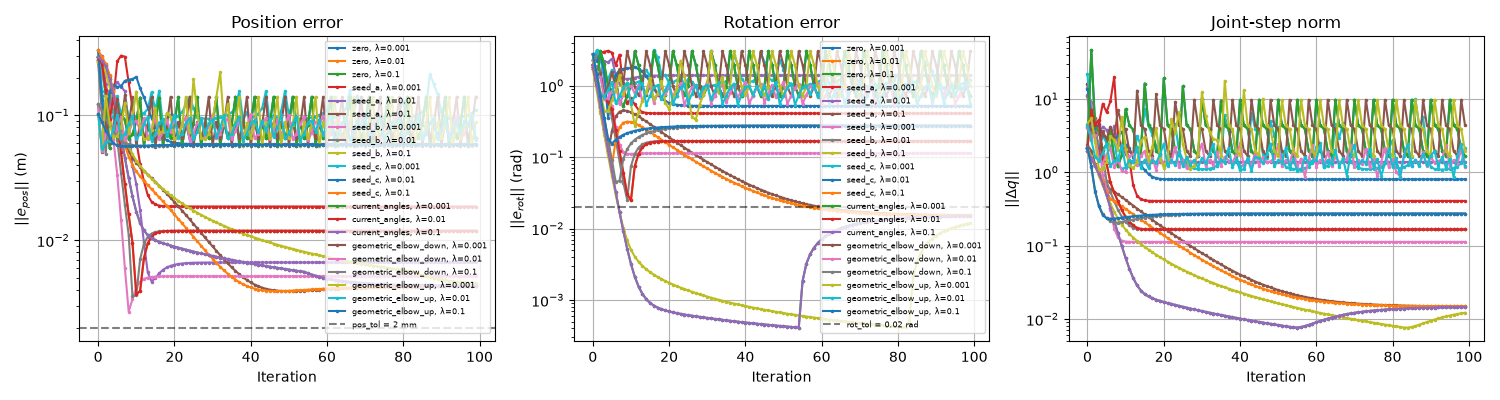

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for run in debug_runs:
    iterations = [entry['iteration'] for entry in run['history']]
    pos_norms = [entry['pos_error_norm'] for entry in run['history']]
    rot_norms = [entry['rot_error_norm'] for entry in run['history']]
    step_norms = [entry['step_norm'] for entry in run['history']]
    label = f"{run['seed']}, λ={run['damping']}"

    axes[0].semilogy(iterations, pos_norms, marker='.', markersize=3, label=label)
    axes[1].semilogy(iterations, rot_norms, marker='.', markersize=3, label=label)
    axes[2].semilogy(iterations, step_norms, marker='.', markersize=3, label=label)

axes[0].set_title('Position error')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel(r'$||e_{pos}||$ (m)')
axes[0].axhline(0.002, color='k', linestyle='--', alpha=0.5, label='pos_tol = 2 mm')
axes[0].grid(True)
axes[0].legend(fontsize=6)

axes[1].set_title('Rotation error')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$||e_{rot}||$ (rad)')
axes[1].axhline(0.02, color='k', linestyle='--', alpha=0.5, label='rot_tol = 0.02 rad')
axes[1].grid(True)
axes[1].legend(fontsize=6)

axes[2].set_title('Joint-step norm')
axes[2].set_xlabel('Iteration')
axes[2].set_ylabel(r'$||\Delta q||$')
axes[2].grid(True)

plt.tight_layout()

### 16. Reproduce the ik_debug.py convergence workflow

The codebase includes `scripts/ik_debug.py`, a standalone script that tests IK convergence on specific target poses and plots iteration-by-iteration error. In this task, replicate that workflow inside the notebook: solve two different target poses from the same seed and overlay their convergence curves. This lets you see how target reachability affects convergence behaviour.

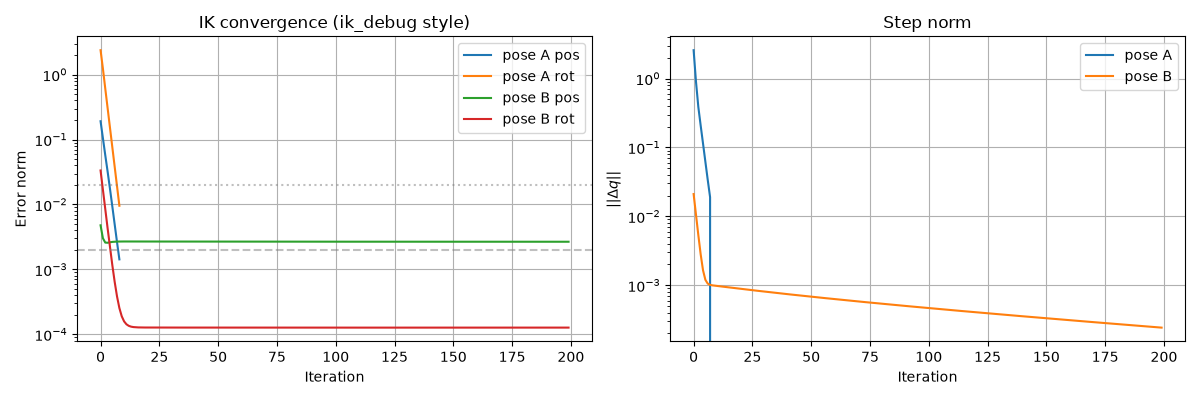

In [45]:
# Two target poses (similar to defaults in ik_debug.py)
pose_a_xyzrpy = [0.0880, -0.0645, 0.2315, 2.337, -0.007, -1.5888]  # m, rad
pose_b_xyzrpy = [0.0502, -0.0639, 0.4194, -1.601, -0.009, -1.5817]  # m, rad

def xyzrpy_to_se3(xyzrpy):
    """Build SE3 from [x, y, z, roll, pitch, yaw] using the codebase RPY convention."""
    return SE3(rpy_to_transform(xyzrpy[:3], xyzrpy[3:6]))

target_a = xyzrpy_to_se3(pose_a_xyzrpy)
target_b = xyzrpy_to_se3(pose_b_xyzrpy)

q0_debug = np.zeros(mycobot.n)

_, hist_a = damped_least_squares_ik(mycobot, bodyname, target_a, q0_debug,
                                     damping=0.05, step=0.5, max_iters=200)
_, hist_b = damped_least_squares_ik(mycobot, bodyname, target_b, q0_debug,
                                     damping=0.05, step=0.5, max_iters=200)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy([h['iteration'] for h in hist_a], [h['pos_error_norm'] for h in hist_a], label='pose A pos')
axes[0].semilogy([h['iteration'] for h in hist_a], [h['rot_error_norm'] for h in hist_a], label='pose A rot')
axes[0].semilogy([h['iteration'] for h in hist_b], [h['pos_error_norm'] for h in hist_b], label='pose B pos')
axes[0].semilogy([h['iteration'] for h in hist_b], [h['rot_error_norm'] for h in hist_b], label='pose B rot')
axes[0].set_title('IK convergence (ik_debug style)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Error norm')
axes[0].axhline(0.002, color='gray', linestyle='--', alpha=0.5)
axes[0].axhline(0.02, color='gray', linestyle=':', alpha=0.5)
axes[0].legend()
axes[0].grid(True)

axes[1].semilogy([h['iteration'] for h in hist_a], [h['step_norm'] for h in hist_a], label='pose A')
axes[1].semilogy([h['iteration'] for h in hist_b], [h['step_norm'] for h in hist_b], label='pose B')
axes[1].set_title('Step norm')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$||\Delta q||$')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()

## Compare Solver Behaviours

### 17. Summarize the three IK approaches

Compare the toolbox IK solution, the generic `least_squares` solution, and your custom damped least-squares Jacobian solution in terms of:

- convergence speed
- final residual
- sensitivity to initialization
- practicality for the myCobot 280 stack

Keep the discussion short and evidence-based. Use the residuals and debug plots rather than guesses.

In [46]:
best_debug_run = min(debug_runs, key=lambda run: run['final_error'])

solver_summary = {
    'toolbox': {
        'q': transform_to_pipi(q_toolbox),
        'residual_norm': np.linalg.norm(poseerror_toolbox),
    },
    'least_squares_lm': {
        'q': transform_to_pipi(q_lm.x),
        'residual_norm': np.linalg.norm(poseerror_lm),
    },
    'dls_custom': {
        'q': transform_to_pipi(best_debug_run['q']),
        'residual_norm': best_debug_run['final_error'],
        'seed': best_debug_run['seed'],
        'damping': best_debug_run['damping'],
    },
}

solver_summary
        


{'toolbox': {'q': array([ 2.92631064,  0.13163988,  2.23645419, -0.26277136, -0.31168526,
         -1.09238192]),
  'residual_norm': np.float64(0.0009562851411229398)},
 'least_squares_lm': {'q': array([ 0.61026107, -0.12201789, -2.18535906,  0.1418266 , -2.99293663,
         -1.78635367]),
  'residual_norm': np.float64(3.317173991891821e-14)},
 'dls_custom': {'q': array([ 0.62340086, -1.90302031,  0.33777856,  2.5307    , -0.15609135,
          1.3442873 ]),
  'residual_norm': np.float64(0.012799511530056425),
  'seed': 'seed_b',
  'damping': 0.1}}

## Bridge to the Live Controller

### 18. Send an IK solution to the real robot

Pick the best IK solution from the solver comparison above and publish it to `/mycobot/joint_command` as a `Float64MultiArray`. The topic expects joint angles in **radians**. The controller converts to degrees internally before sending to the hardware via the serial interface.

This closes the loop: you solved IK offline in the notebook, and now you command the real robot to move to that configuration.

Ensure the `mycobot_control` launch is running in a separate terminal before publishing.

In [47]:
import rclpy
from rclpy.node import Node
from std_msgs.msg import Float64MultiArray

if not rclpy.ok():
    rclpy.init(args=None)

class IKPublisherNode(Node):
    def __init__(self):
        super().__init__('ik_lab_publisher')
        self.pub = self.create_publisher(Float64MultiArray, '/mycobot/joint_command', 10)

ik_node = IKPublisherNode()

# Use the best solution from the solver comparison
q_best = solver_summary['toolbox']['q']  # or replace with your preferred solution

msg = Float64MultiArray()
msg.data = q_best.tolist()
ik_node.pub.publish(msg)
print(f'Published q = {q_best} to /mycobot/joint_command')

rclpy.spin_once(ik_node, timeout_sec=0.5)

# Optional cleanup:
# ik_node.destroy_node()
# rclpy.shutdown()

[WARN] [1790599561.255054942] [rcl.logging_rosout]: Publisher already registered for node name: 'ik_lab_publisher'. If this is due to multiple nodes with the same name then all logs for the logger named 'ik_lab_publisher' will go out over the existing publisher. As soon as any node with that name is destructed it will unregister the publisher, preventing any further logs for that name from being published on the rosout topic.


Published q = [ 2.92631064  0.13163988  2.23645419 -0.26277136 -0.31168526 -1.09238192] to /mycobot/joint_command
